### Import Dependencies

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import os
os.chdir(r'C:\Kaggle_Competition\Playground\S6E5-F1-Pit-Stops')
from pathlib import Path
import numpy as np
import pandas as pd
import gc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.inspection import permutation_importance
import mlflow
import shap

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier
from lightgbm import early_stopping
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping
from catboost import CatBoostClassifier
from pytabkit import RealMLP_TD_Classifier, TabM_D_Classifier
from sklearn.manifold import TSNE

# Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler

# Externals
from src.utils import *
from src.fe import *
import config
import warnings
warnings.filterwarnings('ignore')

### Prepare Datasets

In [14]:
train = read_csv_file('data/raw/train.csv')
test = read_csv_file('data/raw/test.csv')
orig = read_csv_file('data/orig/f1_strategy_dataset_v4.csv')

train = reduce_mem_usage(train)
test = reduce_mem_usage(test)
orig = reduce_mem_usage(orig)

train_ids = train[config.ID_COL].values
test_ids = test[config.ID_COL].values

print(f'Shape of train data: {train.shape}')
print(f'Shape of test data: {test.shape}')
print(f'Shape of orig data: {orig.shape}')

Shape of train data: (439140, 16)
Shape of test data: (188165, 15)
Shape of orig data: (101371, 16)


### Logistic Regression

In [263]:
# Data
train_features = train.drop(['id', config.TARGET], axis=1)
target = train[config.TARGET].values
X_test = test.drop('id', axis=1)

In [259]:
# Predictions
oof_predictions = np.zeros(len(train))
test_predictions = np.zeros(len(X_test))

# Experiment Setup
EXPERIMENT_NAME = "LR"
VERSION = "v2"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(
    n_splits=config.N_FOLDS,
    shuffle=True,
    random_state=config.SEED
)

fold_loglosses = []
fold_aucs = []

with mlflow.start_run(run_name=RUN_NAME):

    for fold, (train_indices, valid_indices) in enumerate(
        skf.split(train_features, target),
        start=1
    ):

        X_train = train_features.iloc[train_indices]
        X_valid = train_features.iloc[valid_indices]

        y_train = target[train_indices]
        y_valid = target[valid_indices]

        preprocessor = ColumnTransformer(
            transformers=[
                ('scaler', StandardScaler(), config.BASE_NUM_COLS),
                ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'), config.BASE_CAT_COLS)
            ],
            remainder='passthrough',
            n_jobs=-1
        )

        X_train_proc = preprocessor.fit_transform(X_train, y_train)
        X_valid_proc = preprocessor.transform(X_valid)
        X_test_proc = preprocessor.transform(X_test)

        model = LogisticRegression(**config.LR_PARAMS)

        model.fit(X_train_proc, y_train)

        fold_oof_predictions = model.predict_proba(X_valid_proc)[:, 1]
        fold_test_predictions = model.predict_proba(X_test_proc)[:, 1]

        oof_predictions[valid_indices] = fold_oof_predictions
        test_predictions += fold_test_predictions / config.N_FOLDS

        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_auc = roc_auc_score(y_valid, fold_oof_predictions)

        fold_loglosses.append(fold_logloss)
        fold_aucs.append(fold_auc)

        print("=" * 50)
        print(f"Fold {fold} LogLoss : {fold_logloss:.5f}")
        print(f"Fold {fold} ROC AUC : {fold_auc:.5f}")
        print("=" * 50)

    oof_logloss = log_loss(target, oof_predictions)
    oof_auc = roc_auc_score(target, oof_predictions)

    std_oof_logloss = np.std(fold_loglosses)
    std_oof_auc = np.std(fold_aucs)

    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_auc", oof_auc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_auc", std_oof_auc)

    mlflow.log_params(config.LR_PARAMS) # Logging params

# Saving predictions
oof_proba_df = pd.DataFrame({'id': train_ids, 'PitNextLap': oof_predictions})
test_proba_df = pd.DataFrame({'id': test_ids, 'PitNextLap': test_predictions})

save_csv_file(oof_proba_df, Path(config.OOF_PROBA_DIR, f'{RUN_NAME}_oof_proba.csv'))
save_csv_file(test_proba_df, Path(config.TEST_PROBA_DIR, f'{RUN_NAME}_test_proba.csv'))

Fold 1 LogLoss : 0.54051
Fold 1 ROC AUC : 0.81122


KeyboardInterrupt: 

In [ ]:
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train_proc.toarray(),
    columns=feature_names
)

explainer = shap.LinearExplainer(
    model=model,
    masker=shap.maskers.Independent(X_train_df)
)

X_valid_df = pd.DataFrame(
    X_valid_proc.toarray(),
    columns=feature_names
)

shap_values = explainer(X_valid_df)

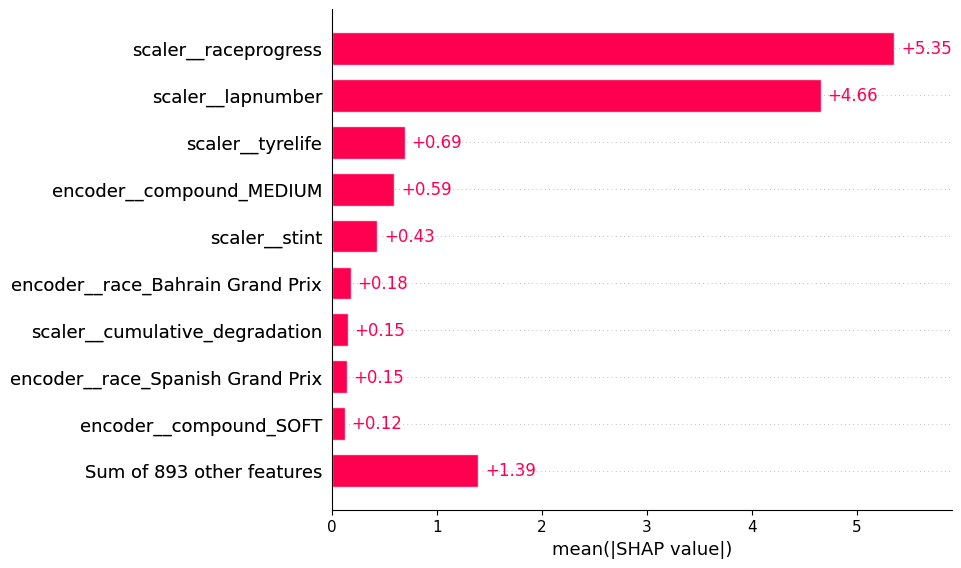

In [90]:
shap.plots.bar(shap_values)

### HistGradientBoosting

In [ ]:
# Data
train_features = train.drop(['id', config.TARGET], axis=1)
target = train[config.TARGET].values
X_test = test.drop('id', axis=1)

In [ ]:
# Predictions
oof_predictions = np.zeros(len(train))
test_predictions = np.zeros(len(X_test))

# Experiment Setup
EXPERIMENT_NAME = "HISTGBM"
VERSION = "v1"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(
    n_splits=config.N_FOLDS,
    shuffle=True,
    random_state=config.SEED
)

fold_loglosses = []
fold_aucs = []

with mlflow.start_run(run_name=RUN_NAME):

    for fold, (train_indices, valid_indices) in enumerate(
        skf.split(train_features, target),
        start=1
    ):
        X_train = train_features.iloc[train_indices]
        X_valid = train_features.iloc[valid_indices]

        y_train = target[train_indices]
        y_valid = target[valid_indices]

        preprocessor = ColumnTransformer(
            transformers=[
                ('encoder', TargetEncoder(target_type='binary', cv=5, shuffle=True, random_state=config.SEED), config.BASE_CAT_COLS)
            ],
            remainder='passthrough',
            n_jobs=-1
        )

        X_train_proc = preprocessor.fit_transform(X_train, y_train)
        X_valid_proc = preprocessor.transform(X_valid)
        X_test_proc = preprocessor.transform(X_test)

        model = HistGradientBoostingClassifier(**config.HISTGBM_PARAMS)

        model.fit(X_train_proc, y_train)

        fold_oof_predictions = model.predict_proba(X_valid_proc)[:, 1]
        fold_test_predictions = model.predict_proba(X_test_proc)[:, 1]

        oof_predictions[valid_indices] = fold_oof_predictions
        test_predictions += fold_test_predictions / config.N_FOLDS

        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_auc = roc_auc_score(y_valid, fold_oof_predictions)

        fold_loglosses.append(fold_logloss)
        fold_aucs.append(fold_auc)

        print("=" * 50)
        print(f"Fold {fold} LogLoss : {fold_logloss:.5f}")
        print(f"Fold {fold} ROC AUC : {fold_auc:.5f}")
        print("=" * 50)

    oof_logloss = log_loss(target, oof_predictions)
    oof_auc = roc_auc_score(target, oof_predictions)

    std_oof_logloss = np.std(fold_loglosses)
    std_oof_auc = np.std(fold_aucs)

    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_auc", oof_auc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_auc", std_oof_auc)

    mlflow.log_params(config.HISTGBM_PARAMS) # Logging params

# Saving predictions
oof_proba_df = pd.DataFrame({'id': train_ids, 'PitNextLap': oof_predictions})
test_proba_df = pd.DataFrame({'id': test_ids, 'PitNextLap': test_predictions})

save_csv_file(oof_proba_df, Path(config.OOF_PROBA_DIR, f'{RUN_NAME}_oof_proba.csv'))
save_csv_file(test_proba_df, Path(config.TEST_PROBA_DIR, f'{RUN_NAME}_test_proba.csv'))

Fold 1 LogLoss : 0.30112
Fold 1 ROC AUC : 0.94608
Fold 2 LogLoss : 0.30216
Fold 2 ROC AUC : 0.94464
Fold 3 LogLoss : 0.30091
Fold 3 ROC AUC : 0.94549
Fold 4 LogLoss : 0.30276
Fold 4 ROC AUC : 0.94436
Fold 5 LogLoss : 0.29760
Fold 5 ROC AUC : 0.94559


### LGBM

In [267]:
# Data
train_features = train.drop(['id', config.TARGET], axis=1)
target = train[config.TARGET].values
X_test = test.drop('id', axis=1)

In [268]:
# Create interaction categorical features
train_features, _ = create_cat_bigrams(train_features, config.BASE_CAT_COLS)
X_test, _ = create_cat_bigrams(X_test, config.BASE_CAT_COLS)

train_features, _ = create_cat_trigrams(train_features, config.BASE_CAT_COLS)
X_test, _ = create_cat_trigrams(X_test, config.BASE_CAT_COLS)

# Factorize categorical columns consistently
cat_cols = train_features.select_dtypes(include='object').columns

for col in cat_cols:
    combined = pd.concat([train_features[col], X_test[col]], axis=0)

    codes, _ = pd.factorize(combined)

    train_features[col] = codes[:len(train_features)].astype('int32')
    X_test[col] = codes[len(train_features):].astype('int32')

Added 6 bigram features
Added 6 bigram features
Added 4 trigram features
Added 4 trigram features


In [269]:
# Predictions
oof_predictions = np.zeros(len(train))
test_predictions = np.zeros(len(X_test))

# Experiment Setup
EXPERIMENT_NAME = "LGBM"
VERSION = "v3"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(
    n_splits=config.N_FOLDS,
    shuffle=True,
    random_state=config.SEED
)

fold_loglosses = []
fold_aucs = []

with mlflow.start_run(run_name=RUN_NAME):

    for fold, (train_indices, valid_indices) in enumerate(
        skf.split(train_features, target),
        start=1
    ):
        X_train = train_features.iloc[train_indices]
        X_valid = train_features.iloc[valid_indices]

        y_train = target[train_indices]
        y_valid = target[valid_indices]

        preprocessor = ColumnTransformer(
            transformers=[
                ('encoder', TargetEncoder(target_type='binary', cv=5, shuffle=True, random_state=config.SEED), config.BASE_CAT_COLS)
            ],
            remainder='passthrough',
            n_jobs=-1
        )

        X_train_proc = preprocessor.fit_transform(X_train, y_train)
        X_valid_proc = preprocessor.transform(X_valid)
        X_test_proc = preprocessor.transform(X_test)

        model = LGBMClassifier(**config.LGBM_PARAMS)

        model.fit(X_train_proc, y_train, eval_set=[(X_valid_proc, y_valid)], callbacks=[early_stopping(100)])

        fold_oof_predictions = model.predict_proba(X_valid_proc)[:, 1]
        fold_test_predictions = model.predict_proba(X_test_proc)[:, 1]

        oof_predictions[valid_indices] = fold_oof_predictions
        test_predictions += fold_test_predictions / config.N_FOLDS

        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_auc = roc_auc_score(y_valid, fold_oof_predictions)

        fold_loglosses.append(fold_logloss)
        fold_aucs.append(fold_auc)

        print("=" * 50)
        print(f"Fold {fold} LogLoss : {fold_logloss:.5f}")
        print(f"Fold {fold} ROC AUC : {fold_auc:.5f}")
        print("=" * 50)

    oof_logloss = log_loss(target, oof_predictions)
    oof_auc = roc_auc_score(target, oof_predictions)

    std_oof_logloss = np.std(fold_loglosses)
    std_oof_auc = np.std(fold_aucs)

    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_auc", oof_auc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_auc", std_oof_auc)

    mlflow.log_params(config.LGBM_PARAMS) # Logging params

# Saving predictions
oof_proba_df = pd.DataFrame({'id': train_ids, 'PitNextLap': oof_predictions})
test_proba_df = pd.DataFrame({'id': test_ids, 'PitNextLap': test_predictions})

save_csv_file(oof_proba_df, Path(config.OOF_PROBA_DIR, f'{RUN_NAME}_oof_proba.csv'))
save_csv_file(test_proba_df, Path(config.TEST_PROBA_DIR, f'{RUN_NAME}_test_proba.csv'))

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3028]	valid_0's auc: 0.947854
Fold 1 LogLoss : 0.28699
Fold 1 ROC AUC : 0.94785
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2973]	valid_0's auc: 0.946275
Fold 2 LogLoss : 0.28806
Fold 2 ROC AUC : 0.94627
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2215]	valid_0's auc: 0.947031
Fold 3 LogLoss : 0.29156
Fold 3 ROC AUC : 0.94703
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2426]	valid_0's auc: 0.945897
Fold 4 LogLoss : 0.29224
Fold 4 ROC AUC : 0.94590
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2448]	valid_0's auc: 0.947261
Fold 5 LogLoss : 0.28808
Fold 5 ROC AUC : 0.94726


### XGBoost

In [15]:
# Data
train_features = train.drop(['id', config.TARGET], axis=1)
target = train[config.TARGET].values
X_test = test.drop('id', axis=1)

In [ ]:
# Predictions
oof_predictions = np.zeros(len(train))
test_predictions = np.zeros(len(X_test))

# Experiment Setup
EXPERIMENT_NAME = "XGB"
VERSION = "v2"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(
    n_splits=config.N_FOLDS,
    shuffle=True,
    random_state=config.SEED
)

fold_loglosses = []
fold_aucs = []

with mlflow.start_run(run_name=RUN_NAME):

    for fold, (train_indices, valid_indices) in enumerate(
        skf.split(train_features, target),
        start=1
    ):
        X_train = train_features.iloc[train_indices]
        X_valid = train_features.iloc[valid_indices]

        y_train = target[train_indices]
        y_valid = target[valid_indices]

        preprocessor = ColumnTransformer(
            transformers=[
                ('encoder', OneHotEncoder(dtype=int, handle_unknown='ignore'), config.BASE_CAT_COLS)
            ],
            remainder='passthrough',
            n_jobs=-1
        )

        X_train_proc = preprocessor.fit_transform(X_train, y_train)
        X_valid_proc = preprocessor.transform(X_valid)
        X_test_proc = preprocessor.transform(X_test)

        early_stop = EarlyStopping(rounds=100, metric_name='auc', save_best=True)
        model = XGBClassifier(**config.XGBM_PARAMS)
        model.fit(X_train_proc, y_train, eval_set=[(X_valid_proc, y_valid)], verbose=200)

        fold_oof_predictions = model.predict_proba(X_valid_proc)[:, 1]
        fold_test_predictions = model.predict_proba(X_test_proc)[:, 1]

        oof_predictions[valid_indices] = fold_oof_predictions
        test_predictions += fold_test_predictions / config.N_FOLDS

        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_auc = roc_auc_score(y_valid, fold_oof_predictions)

        fold_loglosses.append(fold_logloss)
        fold_aucs.append(fold_auc)

        print("=" * 50)
        print(f"Fold {fold} LogLoss : {fold_logloss:.5f}")
        print(f"Fold {fold} ROC AUC : {fold_auc:.5f}")
        print("=" * 50)

    oof_logloss = log_loss(target, oof_predictions)
    oof_auc = roc_auc_score(target, oof_predictions)

    std_oof_logloss = np.std(fold_loglosses)
    std_oof_auc = np.std(fold_aucs)

    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_auc", oof_auc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_auc", std_oof_auc)

    mlflow.log_params(config.XGBM_PARAMS) # Logging params

# Saving predictions
oof_proba_df = pd.DataFrame({'id': train_ids, 'PitNextLap': oof_predictions})
test_proba_df = pd.DataFrame({'id': test_ids, 'PitNextLap': test_predictions})

save_csv_file(oof_proba_df, Path(config.OOF_PROBA_DIR, f'{RUN_NAME}_oof_proba.csv'))
save_csv_file(test_proba_df, Path(config.TEST_PROBA_DIR, f'{RUN_NAME}_test_proba.csv'))